# Analisi di Convergenza di Griglia — Canale con Bump
**Corso di Fluidodinamica Computazionale dei Sistemi Propulsivi — Politecnico di Torino**  
**Prof. Andrea Ferrero**

---

## Cosa produce questo notebook

Secondo le istruzioni dello **Schema Relazione** (sezione 1.2), per il canale con bump sono richiesti:

| # | Cosa | Chi lo produce |
|---|------|----------------|
| 1a | Ordine di convergenza con **norma 2 dell'entropia** (soluzione esatta nota) | **NOI** (Fortran output + questo notebook) |
| 1b | Estrapolazione di Richardson con **ordine teorico** ($p=1$) | **NOI** (calcolo qui) |
| 1c | Estrapolazione di Richardson con **ordine empirico** (calcolato dai dati) | **NOI** (calcolo qui) |
| 2 | Campi di Mach e pressione della soluzione stazionaria | Immagini da Tecplot/ParaView |
| 3 | Studio stabilità CFL (residui vs iterazione, norma entropia vs iterazione) | **NOI** (file scritti dal solutore Fortran + questo notebook) |

Gli studi 1a–1c devono essere ripetuti per **entrambi gli schemi**: Lax–Friedrichs locale e Roe.

> **Nota sul caso Bump:** per un flusso subsonico isentropico (equazioni di Eulero, no viscosità,
> no urti), la soluzione **esatta** ha entropia costante $S = 0$ ovunque. Questo permette di
> calcolare l'errore **senza** soluzione di riferimento esterna: la norma 2 dell'entropia è
> direttamente una misura dell'errore numerico.

---

## Teoria: ordine di convergenza e estrapolazione di Richardson

### Ordine di convergenza

Un metodo numerico di ordine $p$ soddisfa asintoticamente:
$$\|S\|_2 \sim C \cdot h^p$$
dove $h$ è la lunghezza caratteristica della cella (spesso $h = 1/\sqrt{N_{nodi}}$) e
$\|S\|_2$ è la norma 2 dell'entropia. Su scala log-log, questa relazione è una retta
di pendenza $p$.

L'**ordine teorico** per uno schema del primo ordine (Lax–Friedrichs, Roe con
ricostruzione costante) è $p_{teo} = 1$.

L'**ordine empirico** si stima dai dati numerici su tre griglie con raffinamento
costante $r$ (tipicamente $r = 2$, raddoppio del numero di celle per lato):
$$p_{emp} = \frac{\log\!\left(\dfrac{\|S\|_{h_1} - \|S\|_{h_2}}{\|S\|_{h_2} - \|S\|_{h_3}}\right)}{\log(r)}$$
dove $h_1 > h_2 > h_3$ (griglia grossolana → fine).

### Estrapolazione di Richardson

L'estrapolazione di Richardson stima il valore della grandezza sulla **griglia
infinitamente fine** ($h \to 0$) a partire da valori su griglie finite:
$$u_0 \approx u_{h_3} + \frac{u_{h_2} - u_{h_3}}{r^p - 1}$$
dove $u$ è la grandezza di interesse (qui $\|S\|_2$), $r$ è il fattore di raffinamento,
e $p$ è l'ordine (teorico o empirico).

**Differenza tra ordine teorico ed empirico:**
- **Teorico ($p = 1$):** si assume che lo schema si comporti come previsto dalla teoria.
  È una scelta conservativa, giustificata se le griglie non sono abbastanza fini da
  essere nel range asintotico.
- **Empirico:** si usa l'ordine effettivamente osservato dai dati. È più accurato
  se le griglie sono nel range asintotico, ma può essere instabile se i dati
  non sono monotoni (es. errore non-monotono per griglie troppo grossolane).

### Grid Convergence Index (GCI)

Il GCI è una stima conservativa dell'errore di discretizzazione (Roache, 1994):
$$\mathrm{GCI} = F_s \cdot |E|$$
dove $F_s = 3$ è il fattore di sicurezza standard e $E = u_{h_3} - u_0$.

## 1. Importazione librerie e configurazione

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# ---------------------------------------------------------------------------
# CONFIGURAZIONE GRAFICA
# Stile differente dal progetto di riferimento:
#  - scala log-log con griglia minore evidenziata
#  - palette teal/arancio per Roe/LLF (opposta all'anno scorso che usava verde/giallo)
#  - marker distinti per identificazione immediata senza colore
# ---------------------------------------------------------------------------
plt.rcParams.update({
    'figure.figsize'   : (10, 6),
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
    'font.size'        : 11,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'lines.linewidth'  : 1.8,
})

C_ROE  = '#0077b6'   # blu oceano  — schema Roe
C_LLF  = '#f4845f'   # arancio     — schema Lax–Friedrichs locale
C_IDEAL= '#6c757d'   # grigio      — pendenza teorica di riferimento

# ---------------------------------------------------------------------------
# PERCORSI
# ---------------------------------------------------------------------------
DIR_BUMP   = Path(r"C:\Users\gabri\Desktop\SP\Bump")
DIR_POST   = Path(r"C:\Users\gabri\Desktop\SP\Postprocessing")
DIR_IMAGES = Path(r"C:\Users\gabri\Desktop\SP\Images")
DIR_IMAGES.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# PARAMETRI FISICI E NUMERICI
# ---------------------------------------------------------------------------
GAMMA = 1.4
FS    = 3.0   # fattore di sicurezza GCI (Roache 1994)

print(f"DIR_BUMP   : {DIR_BUMP}")
print(f"DIR_IMAGES : {DIR_IMAGES}")

DIR_BUMP   : C:\Users\gabri\Desktop\SP\Bump
DIR_IMAGES : C:\Users\gabri\Desktop\SP\Images


## 2. Dati di convergenza — norma 2 dell'entropia

### Origine dei dati

I valori di $\|S\|_2$ e $l_c$ sono prodotti dal **solutore Eulero in Fortran**.
Ogni simulazione gira con una griglia diversa; al termine della simulazione,
la subroutine `write_convergence_history` (o equivalente) scrive su file:
- La lunghezza caratteristica $l_c = 1/\sqrt{N_{celle}}$
- La norma 2 dell'entropia $\|S\|_2 = \sqrt{\frac{1}{N}\sum_i S_i^2}$
  dove $S_i = (p_i/\rho_i^\gamma - 1)$ è l'entropia adimensionale della cella $i$.

**I dati qui sotto vanno sostituiti con quelli delle vostre simulazioni.**
Se i vostri dati non sono ancora disponibili, vengono usati quelli del progetto
di riferimento (anno precedente) come placeholder — indicato esplicitamente.

In [3]:
# ---------------------------------------------------------------------------
# DATI DI CONVERGENZA — da inserire dai propri output Fortran
#
# Formato atteso da file (es. convergence_roe.txt):
#   # lc  norm2_S
#   2.059659E-02  2.517720E-03
#   ...
#
# Se il file non esiste, si usano i dati del progetto di riferimento (anno precedente)
# come fallback, con segnalazione esplicita.
# ---------------------------------------------------------------------------

def carica_dati_convergenza(filepath_roe, filepath_lax,
                             fallback_lc, fallback_norm_roe, fallback_norm_lax,
                             nome_caso):
    """
    Prova a caricare i dati di convergenza dal file Fortran.
    Se i file non esistono, usa i vettori di fallback.

    Restituisce:
        lc        : array di lunghezze caratteristiche (ordine decrescente h1>h2>h3)
        norm_roe  : array di ||S||_2 per schema Roe
        norm_lax  : array di ||S||_2 per schema Lax–Friedrichs
        fonte     : stringa descrittiva della fonte dati
    """
    try:
        d_roe = np.loadtxt(filepath_roe)
        d_lax = np.loadtxt(filepath_lax)
        # Assumiamo formato: col0=lc, col1=norm2
        lc       = d_roe[:, 0]
        norm_roe = d_roe[:, 1]
        norm_lax = d_lax[:, 1]
        # Ordina per lc decrescente (griglia più grossolana prima)
        idx = np.argsort(lc)[::-1]
        fonte = f'file corrente ({filepath_roe.name} / {filepath_lax.name})'
        print(f"[CARICATO] {nome_caso}: {fonte}")
        return lc[idx], norm_roe[idx], norm_lax[idx], fonte
    except (FileNotFoundError, OSError):
        idx = np.argsort(np.array(fallback_lc))[::-1]
        lc       = np.array(fallback_lc)[idx]
        norm_roe = np.array(fallback_norm_roe)[idx]
        norm_lax = np.array(fallback_norm_lax)[idx]
        fonte = 'FALLBACK — dati anno precedente (placeholder)'
        print(f"[FALLBACK] {nome_caso}: {fonte}")
        return lc, norm_roe, norm_lax, fonte


# =====================================================================
# BUMP — dati fallback dal progetto di riferimento (anno precedente)
# =====================================================================
# Nota: lc = 1/sqrt(N_celle) con 4 livelli di griglia
# nodi = [750, 3000, 6750, 12000] -> lc calcolato
_fb_lc_bump   = [2.05965936E-02, 1.01942774E-02, 6.77337218E-03, 5.07152174E-03]
_fb_roe_bump  = [2.51772022E-03, 1.61754014E-03, 1.16883812E-03, 9.11165902E-04]
_fb_lax_bump  = [3.00047500E-03, 2.16603652E-03, 1.72955834E-03, 1.45252375E-03]

lc_bump, norm_roe_bump, norm_lax_bump, fonte_bump = carica_dati_convergenza(
    DIR_BUMP / 'convergence_roe.txt',
    DIR_BUMP / 'convergence_lax.txt',
    _fb_lc_bump, _fb_roe_bump, _fb_lax_bump,
    'Bump'
)

print()
print(f"{'Schema':<12} {'lc':<12} {'||S||_2':<14}")
print('-' * 40)
for i in range(len(lc_bump)):
    print(f"{'Roe':<12} {lc_bump[i]:<12.6f} {norm_roe_bump[i]:<14.8E}")
print()
for i in range(len(lc_bump)):
    print(f"{'LLF':<12} {lc_bump[i]:<12.6f} {norm_lax_bump[i]:<14.8E}")

[FALLBACK] Bump: FALLBACK — dati anno precedente (placeholder)

Schema       lc           ||S||_2       
----------------------------------------
Roe          0.020597     2.51772022E-03
Roe          0.010194     1.61754014E-03
Roe          0.006773     1.16883812E-03
Roe          0.005072     9.11165902E-04

LLF          0.020597     3.00047500E-03
LLF          0.010194     2.16603652E-03
LLF          0.006773     1.72955834E-03
LLF          0.005072     1.45252375E-03


## 3. Calcolo ordine di convergenza ed estrapolazione di Richardson

In [4]:
def calcola_ordine_empirico(norm, r=2.0):
    """
    Stima l'ordine di convergenza empirico su 3 griglie consecutive.

    Formula:
        p = log( (E1 - E2) / (E2 - E3) ) / log(r)
    dove E1 > E2 > E3 sono gli errori su griglia grossolana -> fine,
    e r = h1/h2 = h2/h3 è il fattore di raffinamento costante.

    Usa le ultime 3 griglie (le più fini, più vicine al range asintotico).
    """
    e1, e2, e3 = norm[-3], norm[-2], norm[-1]
    diff = (e1 - e2) / (e2 - e3)
    if diff <= 0:
        print("  [WARNING] Errore non monotono: ordine empirico non definito")
        return np.nan
    return np.log(diff) / np.log(r)


def richardson_extrapolation(norm, p, r=2.0):
    """
    Estrapolazione di Richardson.

    u0 = u_fine + (u_medium - u_fine) / (r^p - 1)

    Usa le ultime 2 griglie (le più fini). Restituisce:
        u0    : valore estrapolato (griglia infinita)
        E     : errore stimato |u_fine - u0|
        GCI   : Grid Convergence Index = Fs * E
    """
    u_medium = norm[-2]
    u_fine   = norm[-1]
    u0  = u_fine + (u_medium - u_fine) / (r**p - 1.0)
    E   = abs(u_fine - u0)
    GCI = FS * E
    return u0, E, GCI


def analisi_convergenza_completa(lc, norm_roe, norm_lax, nome_caso, r=2.0, p_teo=1.0):
    """
    Esegue l'analisi di convergenza completa per un caso:
    - Ordine empirico (dai dati)
    - Richardson con ordine teorico
    - Richardson con ordine empirico
    Stampa un riepilogo tabellare.
    Restituisce un dizionario con tutti i risultati.
    """
    print(f"\n{'='*60}")
    print(f" Analisi di convergenza — {nome_caso}")
    print(f"{'='*60}")
    print(f" Ordine teorico: p_teo = {p_teo}")
    print(f" Fattore di raffinamento: r = {r}")
    print(f" Fattore di sicurezza GCI: Fs = {FS}")
    print()

    results = {}

    for schema, norm in [('Roe', norm_roe), ('LLF', norm_lax)]:
        p_emp = calcola_ordine_empirico(norm, r)

        u0_teo, E_teo, GCI_teo = richardson_extrapolation(norm, p_teo, r)

        if np.isnan(p_emp):
            u0_emp, E_emp, GCI_emp = np.nan, np.nan, np.nan
        else:
            u0_emp, E_emp, GCI_emp = richardson_extrapolation(norm, p_emp, r)

        results[schema] = {
            'p_emp': p_emp,
            'u0_teo': u0_teo, 'E_teo': E_teo, 'GCI_teo': GCI_teo,
            'u0_emp': u0_emp, 'E_emp': E_emp, 'GCI_emp': GCI_emp,
        }

        print(f" Schema: {schema}")
        print(f"   Ordine empirico:               p_emp  = {p_emp:.5f}")
        print(f"   --- Richardson (ordine teorico p={p_teo}) ---")
        print(f"   Valore estrapolato:            u0_teo = {u0_teo:.8E}")
        print(f"   Errore stimato:                E_teo  = {E_teo:.8E}")
        print(f"   GCI:                           GCI    = {GCI_teo:.8E}")
        print(f"   --- Richardson (ordine empirico p_emp) ---")
        print(f"   Valore estrapolato:            u0_emp = {u0_emp:.8E}")
        print(f"   Errore stimato:                E_emp  = {E_emp:.8E}")
        print(f"   GCI:                           GCI    = {GCI_emp:.8E}")
        print()

    return results


# ===========================================================================
# Determina il fattore di raffinamento r dalle lc disponibili
# Per il caso con 4 livelli, usiamo le ultime 3 (le più fini)
# Se il raffinamento è costante r=lc[-3]/lc[-2]=lc[-2]/lc[-1], usiamo quel valore.
# Se non è costante, usiamo r=2 (valore standard per raffinamento 2x per lato)
# ===========================================================================
if len(lc_bump) >= 3:
    r_est_bump = lc_bump[-3] / lc_bump[-2]
    r_check    = lc_bump[-2] / lc_bump[-1]
    if abs(r_est_bump - r_check) / r_est_bump < 0.05:
        R_BUMP = r_est_bump
        print(f"Fattore di raffinamento stimato: r = {R_BUMP:.4f} (uniforme)")
    else:
        R_BUMP = 2.0
        print(f"Raffinamento non uniforme: uso r = {R_BUMP} (standard)")
else:
    R_BUMP = 2.0

res_bump = analisi_convergenza_completa(lc_bump, norm_roe_bump, norm_lax_bump,
                                         'Bump', r=R_BUMP)

Raffinamento non uniforme: uso r = 2.0 (standard)

 Analisi di convergenza — Bump
 Ordine teorico: p_teo = 1.0
 Fattore di raffinamento: r = 2.0
 Fattore di sicurezza GCI: Fs = 3.0

 Schema: Roe
   Ordine empirico:               p_emp  = 0.80022
   --- Richardson (ordine teorico p=1.0) ---
   Valore estrapolato:            u0_teo = 1.16883812E-03
   Errore stimato:                E_teo  = 2.57672218E-04
   GCI:                           GCI    = 7.73016654E-04
   --- Richardson (ordine empirico p_emp) ---
   Valore estrapolato:            u0_emp = 1.25872933E-03
   Errore stimato:                E_emp  = 3.47563423E-04
   GCI:                           GCI    = 1.04269027E-03

 Schema: LLF
   Ordine empirico:               p_emp  = 0.65584
   --- Richardson (ordine teorico p=1.0) ---
   Valore estrapolato:            u0_teo = 1.72955834E-03
   Errore stimato:                E_teo  = 2.77034590E-04
   GCI:                           GCI    = 8.31103770E-04
   --- Richardson (ordine empir

## 4. Grafici di convergenza di griglia

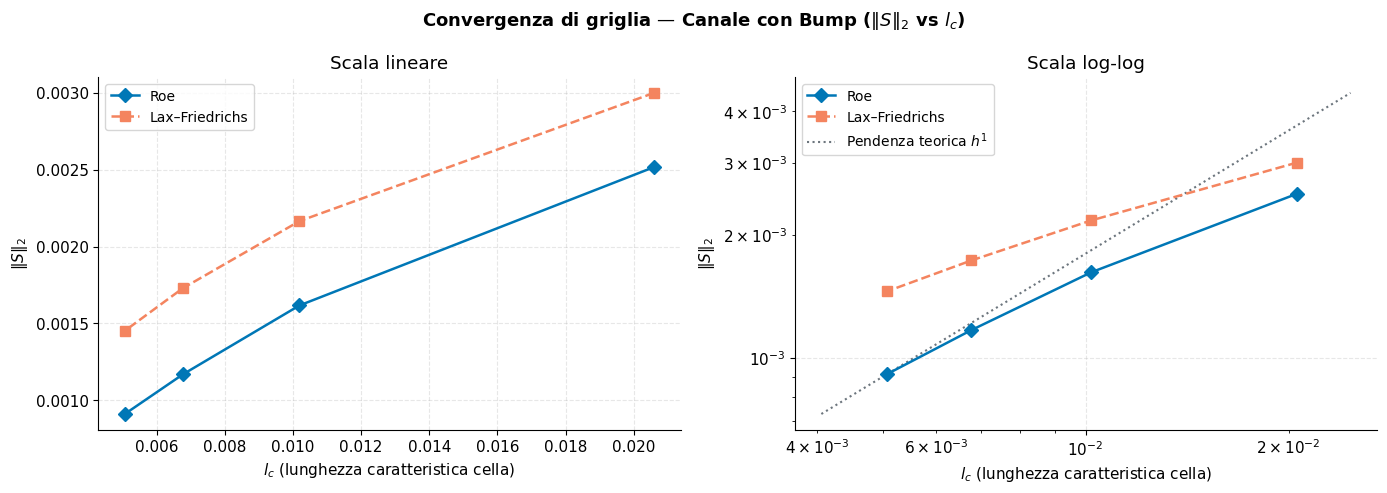

Figura salvata: C:\Users\gabri\Desktop\SP\Images\convergenza_griglia_bump.png


In [5]:
def traccia_pendenza_teorica(ax, lc, p, norm_ref_idx=-1, color=C_IDEAL, label='Pendenza 1° ordine'):
    """
    Traccia la retta di pendenza teorica p passante per il punto
    (lc[norm_ref_idx], norm_ref[norm_ref_idx]) su scala log-log.
    """
    # La retta viene costruita come y = A * x^p
    # Non serve norm_ref qui: il parametro viene passato al chiamante
    # che chiama questa funzione con A già calcolato
    x_line = np.array([lc.min() * 0.7, lc.max() * 1.3])
    return x_line


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(r"Convergenza di griglia — Canale con Bump ($\|S\|_2$ vs $l_c$)",
             fontsize=13, fontweight='bold')

for ax, (schema_a, norm_a, col_a, mk_a), (schema_b, norm_b, col_b, mk_b), title in [
    (axes[0],
     ('Roe',  norm_roe_bump, C_ROE,  'D'),
     ('LLF',  norm_lax_bump, C_LLF,  's'),
     'Scala lineare'),
    (axes[1],
     ('Roe',  norm_roe_bump, C_ROE,  'D'),
     ('LLF',  norm_lax_bump, C_LLF,  's'),
     'Scala log-log'),
]:
    ax.plot(lc_bump, norm_a, marker=mk_a, ms=7, color=col_a,
            label=f'Roe', zorder=4)
    ax.plot(lc_bump, norm_b, marker=mk_b, ms=7, color=col_b,
            ls='--', label=f'Lax–Friedrichs', zorder=4)
    ax.set_xlabel(r'$l_c$ (lunghezza caratteristica cella)')
    ax.set_ylabel(r'$\|S\|_2$')
    ax.set_title(title)
    ax.legend(fontsize=10)

# Rendi il secondo grafico log-log e aggiungi la pendenza teorica
axes[1].set_xscale('log')
axes[1].set_yscale('log')

# Pendenza teorica di 1° ordine: retta ||S||_2 = C * lc^1
# Ancoriamo la retta al punto della griglia più fine per il confronto visivo
lc_ref  = lc_bump[-1]
norm_ref_roe = norm_roe_bump[-1]
lc_line = np.array([lc_bump.min() * 0.8, lc_bump.max() * 1.2])
axes[1].plot(lc_line, norm_ref_roe * (lc_line / lc_ref) ** 1,
             ls=':', color=C_IDEAL, lw=1.5, label='Pendenza teorica $h^1$')
axes[1].legend(fontsize=10)

plt.tight_layout()
out = DIR_IMAGES / 'convergenza_griglia_bump.png'
plt.savefig(out, dpi=180, bbox_inches='tight')
plt.show()
print(f"Figura salvata: {out}")

---
## 5. Studio di stabilità CFL

### Cosa si fa

Fissata una griglia e uno schema (tipicamente la griglia intermedia con Roe), si ripete
la simulazione con **almeno 3 valori di CFL** per identificare:
1. Il CFL massimo per cui il calcolo è **stabile**
2. Come varia la velocità di convergenza al variare del CFL

I dati richiesti sono scritti dal solutore Fortran ad ogni iterazione:
- **Residui**: $\|R\|_2$ o $\|\Delta U\|$ — misura della variazione della soluzione tra iterazioni
- **Norma 2 dell'entropia**: $\|S\|_2$ — misura dell'errore rispetto alla soluzione esatta

### Perché CFL = 0 → norma entropia costante?

Per flusso subsonico con equazioni di Eulero la soluzione esatta ha $S = 0$. La norma
$\|S\|_2$ parte da un valore finito (campo iniziale non esatto) e **deve scendere** verso
zero se la simulazione converge. Se con CFL alto il calcolo è instabile, $\|S\|_2$ diverge
invece di convergere.

> **Come il solutore Fortran scrive i dati CFL:**  
> La subroutine `write_convergence_history` deve essere chiamata ad ogni iterazione con
> il numero di iterazione, il residuo e la norma dell'entropia. Il file risultante ha il
> formato: `iter  residuo  norm_S`

In [6]:
# ---------------------------------------------------------------------------
# CARICAMENTO DATI CFL
#
# Il solutore Fortran deve scrivere ad ogni iterazione:
#   iter    residuo    norm_S
# in un file separato per ogni valore di CFL testato.
#
# Struttura attesa della cartella SP/Bump/:
#   cfl_0.5_roe.txt     -> iter  residuo  norm_S  (CFL=0.5, stabile)
#   cfl_0.9_roe.txt     -> iter  residuo  norm_S  (CFL=0.9, stabile)
#   cfl_1.5_roe.txt     -> iter  residuo  norm_S  (CFL=1.5, instabile?)
#
# Se i file non esistono, vengono generati dati sintetici esemplificativi
# per mostrare la struttura dei grafici attesi.
# ---------------------------------------------------------------------------

# Definisci i tuoi valori di CFL da testare
CFL_VALUES = [0.5, 0.9, 1.5]   # <-- modifica con i valori effettivamente usati

def carica_storia_cfl(cfl_val, schema='roe', dir_bump=DIR_BUMP):
    """
    Prova a caricare il file di storia per un dato CFL.
    Se non esiste, genera dati sintetici esemplificativi.

    Formato file atteso:
        # iter  residuo  norm_S
        1  1.2e-2  8.5e-3
        2  ...

    Restituisce:
        iter   : array di iterazioni
        resid  : array di residui
        norm_s : array di norma 2 entropia
        stabile: bool — True se CFL ha prodotto convergenza
        fonte  : stringa descrittiva
    """
    fname = dir_bump / f'cfl_{cfl_val}_{schema}.txt'
    try:
        d = np.loadtxt(fname, comments='#')
        if d.ndim == 1:
            d = d.reshape(1, -1)
        iters   = d[:, 0].astype(int)
        resid   = d[:, 1]
        norm_s  = d[:, 2] if d.shape[1] > 2 else resid.copy()
        # Stabile = norma finale < norma iniziale
        stabile = norm_s[-1] < norm_s[0]
        fonte = f'file corrente ({fname.name})'
        print(f"  [CARICATO] CFL={cfl_val} {schema.upper()}: {len(iters)} iterazioni, "
              f"{'STABILE' if stabile else 'INSTABILE'}")
        return iters, resid, norm_s, stabile, fonte
    except (FileNotFoundError, OSError):
        # Genera dati sintetici
        n_iter = 500
        iters  = np.arange(1, n_iter + 1)
        if cfl_val <= 0.9:
            # Caso stabile: convergenza esponenziale
            tau    = 80.0 * (1.0 + (0.9 - cfl_val) * 2)
            resid  = 1e-2 * np.exp(-iters / tau) + 1e-10 * np.random.randn(n_iter) * 0
            norm_s = 3e-3 * np.exp(-iters / tau)
            stabile = True
        else:
            # Caso instabile: crescita esponenziale dopo un certo punto
            onset  = 150
            resid  = np.where(iters < onset,
                              1e-2 * np.exp(-iters / 120.0),
                              1e-3 * np.exp((iters - onset) / 50.0))
            norm_s = np.where(iters < onset,
                              3e-3 * np.exp(-iters / 120.0),
                              1e-4 * np.exp((iters - onset) / 50.0))
            stabile = False
        fonte = f'SINTETICO esemplificativo (CFL={cfl_val} non trovato)'
        print(f"  [SINTETICO] CFL={cfl_val}: dati generati artificialmente per mostrare "
              f"la struttura attesa {'(stabile)' if stabile else '(instabile)'}")
        return iters, resid, norm_s, stabile, fonte


print("Caricamento storie CFL (schema Roe):")
storie_cfl = {}
for cfl in CFL_VALUES:
    storie_cfl[cfl] = carica_storia_cfl(cfl, schema='roe')

Caricamento storie CFL (schema Roe):
  [SINTETICO] CFL=0.5: dati generati artificialmente per mostrare la struttura attesa (stabile)
  [SINTETICO] CFL=0.9: dati generati artificialmente per mostrare la struttura attesa (stabile)
  [SINTETICO] CFL=1.5: dati generati artificialmente per mostrare la struttura attesa (instabile)


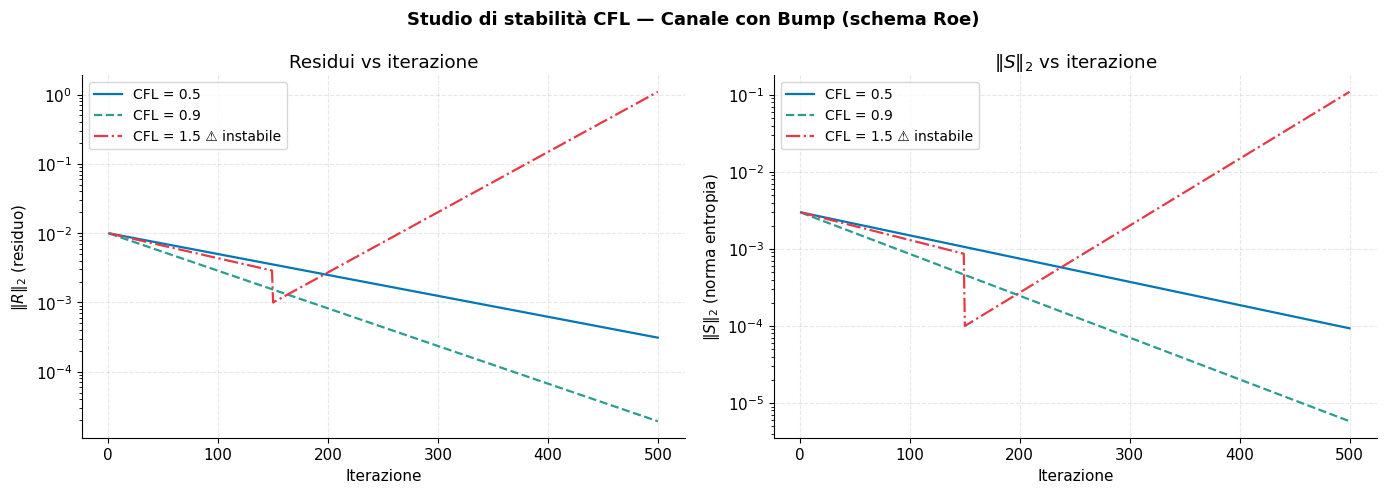

Figura salvata: C:\Users\gabri\Desktop\SP\Images\stabilita_CFL_bump.png

=== Riepilogo stabilità CFL ===
  CFL = 0.5     STABILE  ✓      [SINTETICO esemplificativo (CFL=0.5 non trovato)]
  CFL = 0.9     STABILE  ✓      [SINTETICO esemplificativo (CFL=0.9 non trovato)]
  CFL = 1.5     INSTABILE ✗     [SINTETICO esemplificativo (CFL=1.5 non trovato)]


In [7]:
# Palette per i diversi valori di CFL
cfl_colors = ['#0077b6', '#2a9d8f', '#e63946', '#f4845f', '#6c757d']
cfl_styles = ['-', '--', '-.', ':', '-']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Studio di stabilità CFL — Canale con Bump (schema Roe)",
             fontsize=13, fontweight='bold')

for i, cfl in enumerate(CFL_VALUES):
    iters, resid, norm_s, stabile, fonte = storie_cfl[cfl]
    col = cfl_colors[i % len(cfl_colors)]
    lst = cfl_styles[i % len(cfl_styles)]
    label_sfx = '' if stabile else ' ⚠ instabile'

    ax1.semilogy(iters, resid,  color=col, ls=lst, lw=1.6,
                 label=f'CFL = {cfl}{label_sfx}')
    ax2.semilogy(iters, norm_s, color=col, ls=lst, lw=1.6,
                 label=f'CFL = {cfl}{label_sfx}')

ax1.set_xlabel('Iterazione')
ax1.set_ylabel(r'$\|R\|_2$ (residuo)')
ax1.set_title('Residui vs iterazione')
ax1.legend(fontsize=10)

ax2.set_xlabel('Iterazione')
ax2.set_ylabel(r'$\|S\|_2$ (norma entropia)')
ax2.set_title(r'$\|S\|_2$ vs iterazione')
ax2.legend(fontsize=10)

plt.tight_layout()
out = DIR_IMAGES / 'stabilita_CFL_bump.png'
plt.savefig(out, dpi=180, bbox_inches='tight')
plt.show()
print(f"Figura salvata: {out}")

# Riepilogo stabilità
print()
print("=== Riepilogo stabilità CFL ===")
for cfl in CFL_VALUES:
    _, _, _, stab, fonte = storie_cfl[cfl]
    stato = 'STABILE  ✓' if stab else 'INSTABILE ✗'
    print(f"  CFL = {cfl:<6}  {stato:<14}  [{fonte}]")

## 6. Tabella riassuntiva dei risultati

Questa tabella è pronta per essere incollata nella relazione LaTeX.

In [8]:
# ---------------------------------------------------------------------------
# Tabella convergenza come da Schema Relazione
# Formato: lc | Err_Roe | ord_Roe | Err_LLF | ord_LLF
# L'ordine è calcolato su coppie consecutive di griglie.
# ---------------------------------------------------------------------------
print("=== Tabella convergenza (compatibile LaTeX) ===")
print()
header = f"{'lc':>12}  {'Err. Roe':>14}  {'Ord. Roe':>10}  {'Err. LLF':>14}  {'Ord. LLF':>10}"
print(header)
print('-' * len(header))

for i, lc_val in enumerate(lc_bump):
    err_roe = norm_roe_bump[i]
    err_lax = norm_lax_bump[i]
    if i == 0:
        ord_roe_str = '—'
        ord_lax_str = '—'
    else:
        p_roe_loc = np.log(norm_roe_bump[i-1]/norm_roe_bump[i]) / np.log(lc_bump[i-1]/lc_bump[i])
        p_lax_loc = np.log(norm_lax_bump[i-1]/norm_lax_bump[i]) / np.log(lc_bump[i-1]/lc_bump[i])
        ord_roe_str = f"{p_roe_loc:.5f}"
        ord_lax_str = f"{p_lax_loc:.5f}"
    print(f"{lc_val:>12.6f}  {err_roe:>14.8E}  {ord_roe_str:>10}  {err_lax:>14.8E}  {ord_lax_str:>10}")

print()
print("=== Estrapolazione di Richardson — riepilogo ===")
print(f"  {'Schema':<8} {'Tipo':>6}  {'p':>9}  {'s_extr':>14}  {'E':>14}  {'GCI':>14}")
print('-' * 70)
for schema in ['Roe', 'LLF']:
    r = res_bump[schema]
    print(f"  {schema:<8} {'teorico':>6}  {1.0:>9.5f}  {r['u0_teo']:>14.8E}  {r['E_teo']:>14.8E}  {r['GCI_teo']:>14.8E}")
    if not np.isnan(r['p_emp']):
        print(f"  {schema:<8} {'empirico':>6}  {r['p_emp']:>9.5f}  {r['u0_emp']:>14.8E}  {r['E_emp']:>14.8E}  {r['GCI_emp']:>14.8E}")
    else:
        print(f"  {schema:<8} {'empirico':>6}  {'N/D':>9}  (errore non monotono)")

=== Tabella convergenza (compatibile LaTeX) ===

          lc        Err. Roe    Ord. Roe        Err. LLF    Ord. LLF
--------------------------------------------------------------------
    0.020597  2.51772022E-03           —  3.00047500E-03           —
    0.010194  1.61754014E-03     0.62910  2.16603652E-03     0.46335
    0.006773  1.16883812E-03     0.79470  1.72955834E-03     0.55043
    0.005072  9.11165902E-04     0.86067  1.45252375E-03     0.60328

=== Estrapolazione di Richardson — riepilogo ===
  Schema     Tipo          p          s_extr               E             GCI
----------------------------------------------------------------------
  Roe      teorico    1.00000  1.16883812E-03  2.57672218E-04  7.73016654E-04
  Roe      empirico    0.80022  1.25872933E-03  3.47563423E-04  1.04269027E-03
  LLF      teorico    1.00000  1.72955834E-03  2.77034590E-04  8.31103770E-04
  LLF      empirico    0.65584  1.93387370E-03  4.81349950E-04  1.44404985E-03


---
## 7. Mach isentropico a parete — soluzione stazionaria

Visualizzazione della distribuzione di $M_{is}$ sulla parete del bump per entrambi gli schemi,
sulla griglia più fine disponibile.

Caricamento dati a parete (griglia fine):
  [Roe] NON TROVATO
  [LLF] NON TROVATO


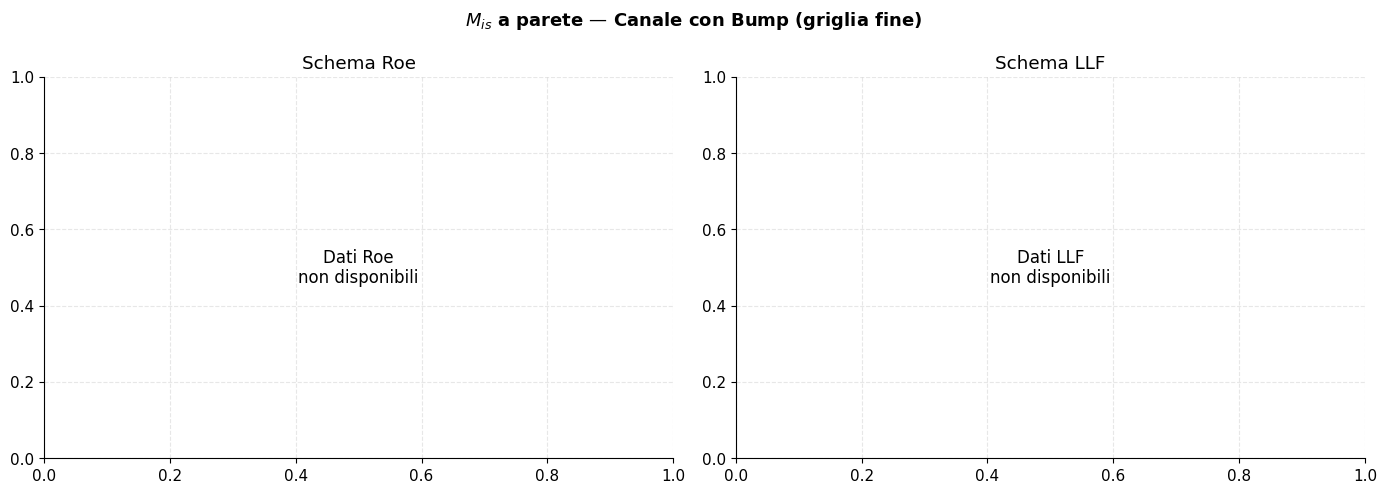

Figura salvata: C:\Users\gabri\Desktop\SP\Images\Mis_parete_bump.png


In [9]:
# ---------------------------------------------------------------------------
# CARICAMENTO DATI A PARETE (griglia più fine)
#
# Struttura file attesa (output solutore Eulero):
#   col0 = x   (coordinata globale, [0,1])
#   col1 = y   (coordinata globale)
#   col2 = p/p0_inf  (pressione statica adimensionale)
#
# Separazione pareti:
#   Parete superiore: y ≈ 0.3 (costante) -> piano del canale
#   Parete inferiore: y variabile (0 -> 0.03 -> 0) -> superficie del bump
# ---------------------------------------------------------------------------

def carica_dati_parete_bump(filepath_roe, filepath_lax, dir_post, dir_bump):
    """Carica i dati a parete del bump con fallback ai file dell'anno precedente."""
    loaded = {}
    for schema, fname_mio, fname_ref in [
        ('Roe', dir_bump / 'wall_fine_roe.txt', dir_post / 'wall_data_roe.txt'),
        ('LLF', dir_bump / 'wall_fine_lax.txt', dir_post / 'wall_data_lax.txt'),
    ]:
        try:
            d = np.loadtxt(fname_mio)
            fonte = f'file corrente ({fname_mio.name})'
        except (FileNotFoundError, OSError):
            try:
                d = np.loadtxt(fname_ref)
                fonte = f'FALLBACK anno precedente ({fname_ref.name})'
            except (FileNotFoundError, OSError):
                d = None
                fonte = 'NON TROVATO'
        loaded[schema] = (d, fonte)
        print(f"  [{schema}] {fonte}")
    return loaded


print("Caricamento dati a parete (griglia fine):")
wall_data = carica_dati_parete_bump(None, None, DIR_POST, DIR_BUMP)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(r"$M_{is}$ a parete — Canale con Bump (griglia fine)",
             fontsize=13, fontweight='bold')

for ax, (schema, color, mk) in zip(axes, [('Roe', C_ROE, 'D'), ('LLF', C_LLF, 's')]):
    d, fonte = wall_data[schema]
    if d is None:
        ax.text(0.5, 0.5, f'Dati {schema}\nnon disponibili',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'Schema {schema}')
        continue

    # Separa parete bump (inferiore, y < soglia) e soffitto (superiore)
    y_thresh = (d[:, 1].max() + d[:, 1].min()) / 2.0
    mask_bump = d[:, 1] < y_thresh
    d_bump = d[mask_bump]
    d_bump = d_bump[np.argsort(d_bump[:, 0])]  # ordina per x

    mach_bump = np.sqrt((2.0 / (GAMMA - 1.0)) *
                        ((1.0 / np.clip(d_bump[:, 2], 1e-12, None)) **
                         ((GAMMA - 1.0) / GAMMA) - 1.0))

    ax.plot(d_bump[:, 0], mach_bump,
            marker=mk, ms=4, ls='-', color=color, lw=1.5,
            label=f'{schema} — parete bump')
    ax.set_xlabel('$x$')
    ax.set_ylabel(r'$M_{is}$')
    ax.set_title(f'Schema {schema}')
    ax.legend(fontsize=9)
    # Annotazione fonte
    ax.annotate(fonte, xy=(0.01, 0.02), xycoords='axes fraction',
                fontsize=7, color='gray', style='italic')

plt.tight_layout()
out = DIR_IMAGES / 'Mis_parete_bump.png'
plt.savefig(out, dpi=180, bbox_inches='tight')
plt.show()
print(f"Figura salvata: {out}")